# **Extracting Information from Legal Documents Using RAG**

## **Objective**

The main objective of this assignment is to process and analyse a collection text files containing legal agreements (e.g., NDAs) to prepare them for implementing a **Retrieval-Augmented Generation (RAG)** system. This involves:

* Understand the Cleaned Data : Gain a comprehensive understanding of the structure, content, and context of the cleaned dataset.
* Perform Exploratory Analysis : Conduct bivariate and multivariate analyses to uncover relationships and trends within the cleaned data.
* Create Visualisations : Develop meaningful visualisations to support the analysis and make findings interpretable.
* Derive Insights and Conclusions : Extract valuable insights from the cleaned data and provide clear, actionable conclusions.
* Document the Process : Provide a detailed description of the data, its attributes, and the steps taken during the analysis for reproducibility and clarity.

The ultimate goal is to transform the raw text data into a clean, structured, and analysable format that can be effectively used to build and train a RAG system for tasks like information retrieval, question-answering, and knowledge extraction related to legal agreements.

### **Business Value**  


The project aims to leverage RAG to enhance legal document processing for businesses, law firms, and regulatory bodies. The key business objectives include:

* Faster Legal Research: <br> Reduce the time lawyers and compliance officers spend searching for relevant case laws, precedents, statutes, or contract clauses.
* Improved Contract Analysis: <br> Automatically extract key terms, obligations, and risks from lengthy contracts.
* Regulatory Compliance Monitoring: <br> Help businesses stay updated with legal and regulatory changes by retrieving relevant legal updates.
* Enhanced Decision-Making: <br> Provide accurate and context-aware legal insights to assist in risk assessment and legal strategy.


**Use Cases**
* Legal Chatbots
* Contract Review Automation
* Tracking Regulatory Changes and Compliance Monitoring
* Case Law Analysis of past judgments
* Due Diligence & Risk Assessment

## **1. Data Loading, Preparation and Analysis** <font color=red> [20 marks] </font><br>

### **1.1 Data Understanding**

The dataset contains legal documents and contracts collected from various sources. The documents are present as text files (`.txt`) in the *corpus* folder.

There are four types of documents in the *courpus* folder, divided into four subfolders.
- `contractnli`: contains various non-disclosure and confidentiality agreements
- `cuad`: contains contracts with annotated legal clauses
- `maud`: contains various merger/acquisition contracts and agreements
- `privacy_qa`: a question-answering dataset containing privacy policies

The dataset also contains evaluation files in JSON format in the *benchmark* folder. The files contain the questions and their answers, along with sources. For each of the above four folders, there is a `json` file: `contractnli.json`, `cuad.json`, `maud.json` `privacy_qa.json`. The file structure is as follows:

```
{
    "tests": [
        {
            "query": <question1>,
            "snippets": [{
                    "file_path": <source_file1>,
                    "span": [ begin_position, end_position ],
                    "answer": <relevant answer to the question 1>
                },
                {
                    "file_path": <source_file2>,
                    "span": [ begin_position, end_position ],
                    "answer": <relevant answer to the question 2>
                }, ....
            ]
        },
        {
            "query": <question2>,
            "snippets": [{<answer context for que 2>}]
        },
        ... <more queries>
    ]
}
```

### **1.2 Load and Preprocess the data** <font color=red> [5 marks] </font><br>

#### Loading libraries

In [3]:
# The following libraries might be useful
!pip install -q langchain-openai
!pip install -U -q langchain-community
!pip install -U -q langchain-chroma
!pip install -U -q datasets
!pip install -U -q ragas
!pip install -U -q rouge_score

In [5]:
# Import essential libraries
import os
import re
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

warnings.filterwarnings('ignore')

# Download required NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

C:\Users\Ismail\AppData\Local\Temp\ipykernel_9140\3583294793.py:22: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma


True

#### **1.2.1** <font color=red> [3 marks] </font>
Load all `.txt` files from the folders.

You can utilise document loaders from the options provided by the LangChain community.

Optionally, you can also read the files manually, while ensuring proper handling of encoding issues (e.g., utf-8, latin1). In such case, also store the file content along with metadata (e.g., file name, directory path) for traceability.

In [6]:
# Load the files as documents

# Path to the corpus folder — adjust if running from a different working directory
CORPUS_DIR = Path('rag_legal/corpus')

documents = []  # list of LangChain Document objects

for txt_file in sorted(CORPUS_DIR.rglob('*.txt')):
    # try utf-8 first, fall back to latin-1 for special characters
    for enc in ('utf-8', 'latin-1'):
        try:
            text = txt_file.read_text(encoding=enc)
            doc = Document(
                page_content=text,
                metadata={
                    'source': str(txt_file),
                    'file_name': txt_file.name,
                    'category': txt_file.parent.name,
                    'relative_path': str(txt_file.relative_to(CORPUS_DIR))
                }
            )
            documents.append(doc)
            break
        except Exception as e:
            continue

print(f'Total documents loaded: {len(documents)}')
print(f'Categories: {set(d.metadata["category"] for d in documents)}')
print('\nSample document metadata:', documents[0].metadata)
print('\nSample text (first 300 chars):\n', documents[0].page_content[:300])

Total documents loaded: 698
Categories: {'maud', 'cuad', 'privacy_qa', 'contractnli'}

Sample document metadata: {'source': 'rag_legal\\corpus\\contractnli\\01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt', 'file_name': '01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt', 'category': 'contractnli', 'relative_path': 'contractnli\\01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt'}

Sample text (first 300 chars):
 MUTUAL NON-DISCLOSURE AGREEMENT
Between
AND
Subject Matter:
Effective Date of Agreement: Period , 2017
for Exchange of Information: , 2017 to
Period of Confidentiality:
THIS AGREEMENT is made as of the Effective Date of Agreement noted above, by and between the above parties.
BACKGROUND:
I. The part


#### **1.2.2** <font color=red> [2 marks] </font>
Preprocess the text data to remove noise and prepare it for analysis.

Remove special characters, extra whitespace, and irrelevant content such as email and telephone contact info.
Normalise text (e.g., convert to lowercase, remove stop words).
Handle missing or corrupted data by logging errors and skipping problematic files.

In [7]:
# Clean and preprocess the data

STOP_WORDS = set(stopwords.words('english'))

def preprocess_text(text: str) -> str:
    """Remove noise from legal text while preserving semantic content."""
    # remove email addresses
    text = re.sub(r'\S+@\S+\.\S+', '', text)
    # remove phone numbers (various formats)
    text = re.sub(r'(\+?\d[\d\s\-().]{7,}\d)', '', text)
    # remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # remove special characters except basic punctuation
    text = re.sub(r'[^\w\s.,;:\-\'"()]', ' ', text)
    # collapse multiple whitespace/newlines
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalise_text(text: str) -> str:
    """Lowercase and remove stop words — used for EDA/frequency analysis only."""
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in STOP_WORDS]
    return ' '.join(tokens)

# apply cleaning to all documents
for doc in documents:
    doc.page_content = preprocess_text(doc.page_content)

# keep a normalised copy for EDA (not used for embeddings)
normalised_texts = [normalise_text(doc.page_content) for doc in documents]

print('Preprocessing complete.')
print('Sample cleaned text (first 300 chars):\n', documents[0].page_content[:300])

Preprocessing complete.
Sample cleaned text (first 300 chars):
 MUTUAL NON-DISCLOSURE AGREEMENT Between AND Subject Matter: Effective Date of Agreement: Period , 2017 for Exchange of Information: , 2017 to Period of Confidentiality: THIS AGREEMENT is made as of the Effective Date of Agreement noted above, by and between the above parties. BACKGROUND: I. The part


### **1.3 Exploratory Data Analysis** <font color=red> [10 marks] </font><br>

#### **1.3.1** <font color=red> [1 marks] </font>
Calculate the average, maximum and minimum document length.

Document length statistics (characters):
  Average : 102,049
  Maximum : 982,920  → Contango_Oil_&_Gas_KKR_&_Co.txt
  Minimum : 1,438  → GALACTICOMMTECHNOLOGIESINC_11_07_1997-EX-10.46-WEB HOSTING AGREEMENT.txt


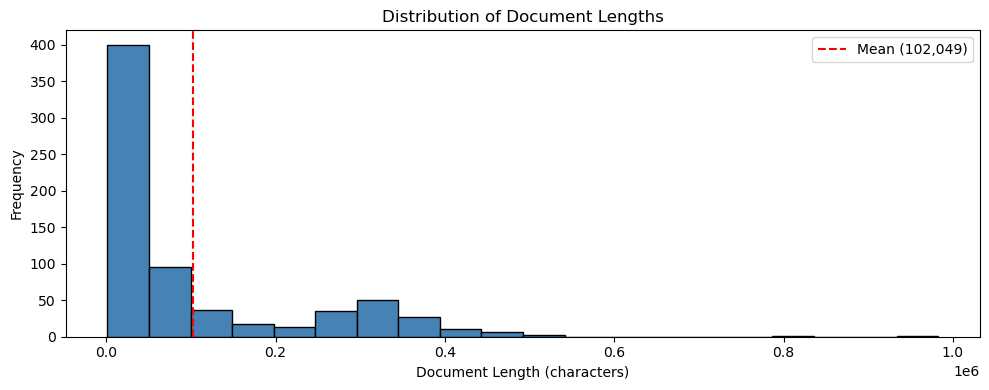

In [8]:
# Calculate the average, maximum and minimum document length.

doc_lengths = [len(doc.page_content) for doc in documents]

avg_len = np.mean(doc_lengths)
max_len = np.max(doc_lengths)
min_len = np.min(doc_lengths)

print(f'Document length statistics (characters):')
print(f'  Average : {avg_len:,.0f}')
print(f'  Maximum : {max_len:,.0f}  → {documents[np.argmax(doc_lengths)].metadata["file_name"]}')
print(f'  Minimum : {min_len:,.0f}  → {documents[np.argmin(doc_lengths)].metadata["file_name"]}')

# visualise distribution
plt.figure(figsize=(10, 4))
plt.hist(doc_lengths, bins=20, edgecolor='black', color='steelblue')
plt.axvline(avg_len, color='red', linestyle='--', label=f'Mean ({avg_len:,.0f})')
plt.xlabel('Document Length (characters)')
plt.ylabel('Frequency')
plt.title('Distribution of Document Lengths')
plt.legend()
plt.tight_layout()
plt.show()

#### **1.3.2** <font color=red> [4 marks] </font>
Analyse the frequency of occurrence of words and find the most and least occurring words.

Find the 20 most common and least common words in the text. Ignore stop words such as articles and prepositions.

Top 20 most common words:
  company: 156123
  shall: 108016
  agreement: 104635
  section: 75352
  parent: 60660
  party: 53104
  date: 39338
  time: 35435
  material: 34213
  merger: 33850
  subsidiaries: 33320
  b: 32407
  applicable: 31371
  including: 29403
  respect: 28848
  may: 28069
  stock: 26648
  information: 25716
  parties: 24617
  business: 23545

Top 20 least common words:
  newer: 1
  vungle: 1
  tapresearch: 1
  tapjoy: 1
  soomla: 1
  smaato: 1
  pinsight: 1
  nativex: 1
  loopme: 1
  lifestreet: 1
  kongregate: 1
  ironsource: 1
  inmobi: 1
  hyprmx: 1
  heyzap: 1
  fyber: 1
  chartboost: 1
  applovin: 1
  aerserv: 1
  deltadna: 1


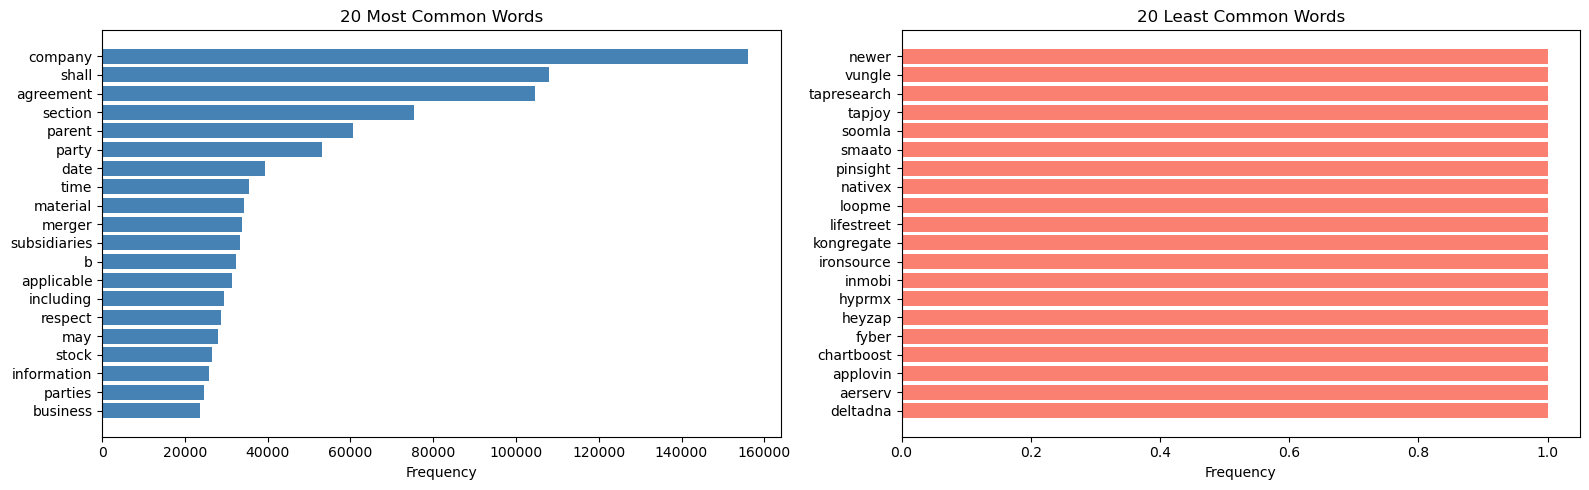

In [9]:
# Find frequency of occurence of words

# tokenise all normalised texts and build a global vocabulary frequency
all_tokens = []
for text in normalised_texts:
    all_tokens.extend(text.split())

word_freq = Counter(all_tokens)

# 20 most common words
most_common = word_freq.most_common(20)
least_common = word_freq.most_common()[:-21:-1]  # 20 least common

print('Top 20 most common words:')
for word, count in most_common:
    print(f'  {word}: {count}')

print('\nTop 20 least common words:')
for word, count in least_common:
    print(f'  {word}: {count}')

# plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

words_mc, counts_mc = zip(*most_common)
axes[0].barh(words_mc, counts_mc, color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('20 Most Common Words')
axes[0].set_xlabel('Frequency')

words_lc, counts_lc = zip(*least_common)
axes[1].barh(words_lc, counts_lc, color='salmon')
axes[1].invert_yaxis()
axes[1].set_title('20 Least Common Words')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

#### **1.3.3** <font color=red> [4 marks] </font>
Analyse the similarity of different documents to each other based on TF-IDF vectors.

Transform some documents to TF-IDF vectors and calculate their similarity matrix using a suitable distance function. If contracts contain duplicate or highly similar clauses, similarity calculation can help detect them.

Identify for the first 10 documents and then for 10 random documents. What do you observe?

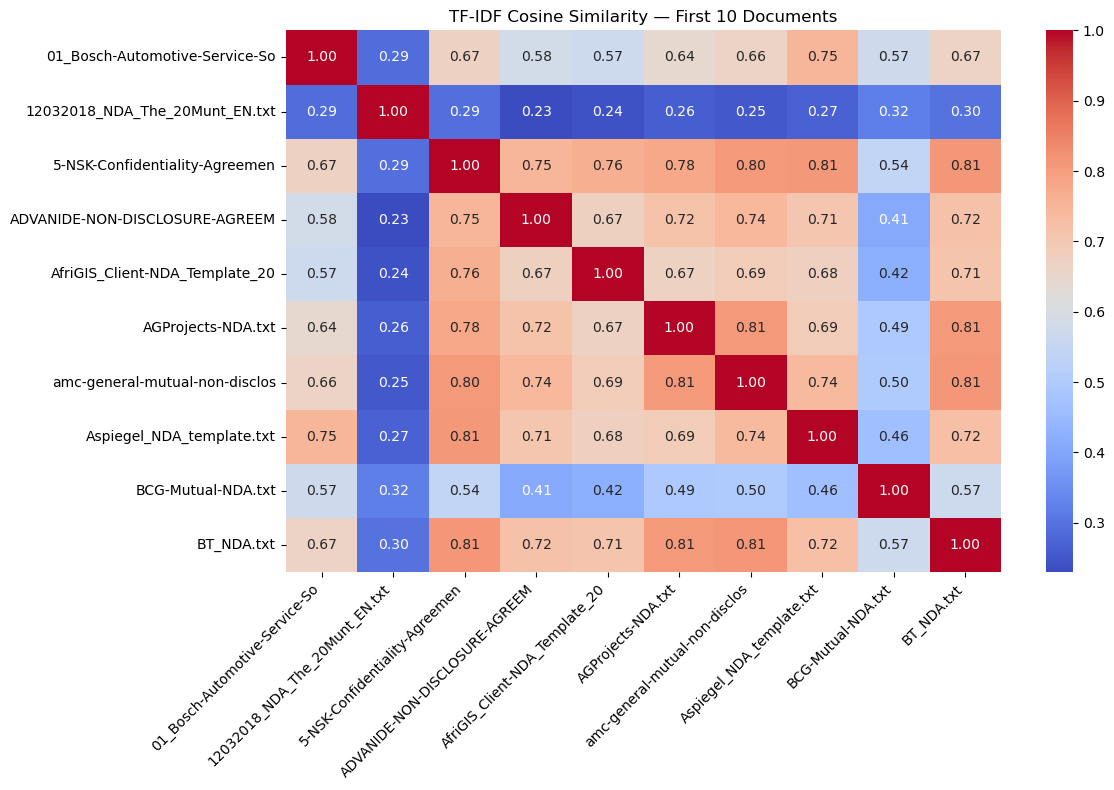


Observation: Documents from the same legal category tend to have higher similarity.
Cross-category pairs show lower similarity, reflecting distinct vocabulary per document type.


In [10]:
# Transform the page contents of documents

tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform([doc.page_content for doc in documents])

# Compute similarity scores
first10_matrix = tfidf_matrix[:10]
sim_matrix_first10 = cosine_similarity(first10_matrix)

# plot heatmap for first 10 documents
labels_first10 = [documents[i].metadata['file_name'][:30] for i in range(10)]
plt.figure(figsize=(12, 8))
sns.heatmap(
    sim_matrix_first10,
    xticklabels=labels_first10,
    yticklabels=labels_first10,
    annot=True, fmt='.2f', cmap='coolwarm'
)
plt.title('TF-IDF Cosine Similarity — First 10 Documents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nObservation: Documents from the same legal category tend to have higher similarity.')
print('Cross-category pairs show lower similarity, reflecting distinct vocabulary per document type.')

In [11]:
# create a list of 10 random integers

random.seed(42)
random_indices = random.sample(range(len(documents)), 10)
print('Random document indices:', random_indices)

Random document indices: [654, 114, 25, 281, 250, 228, 142, 104, 692, 558]


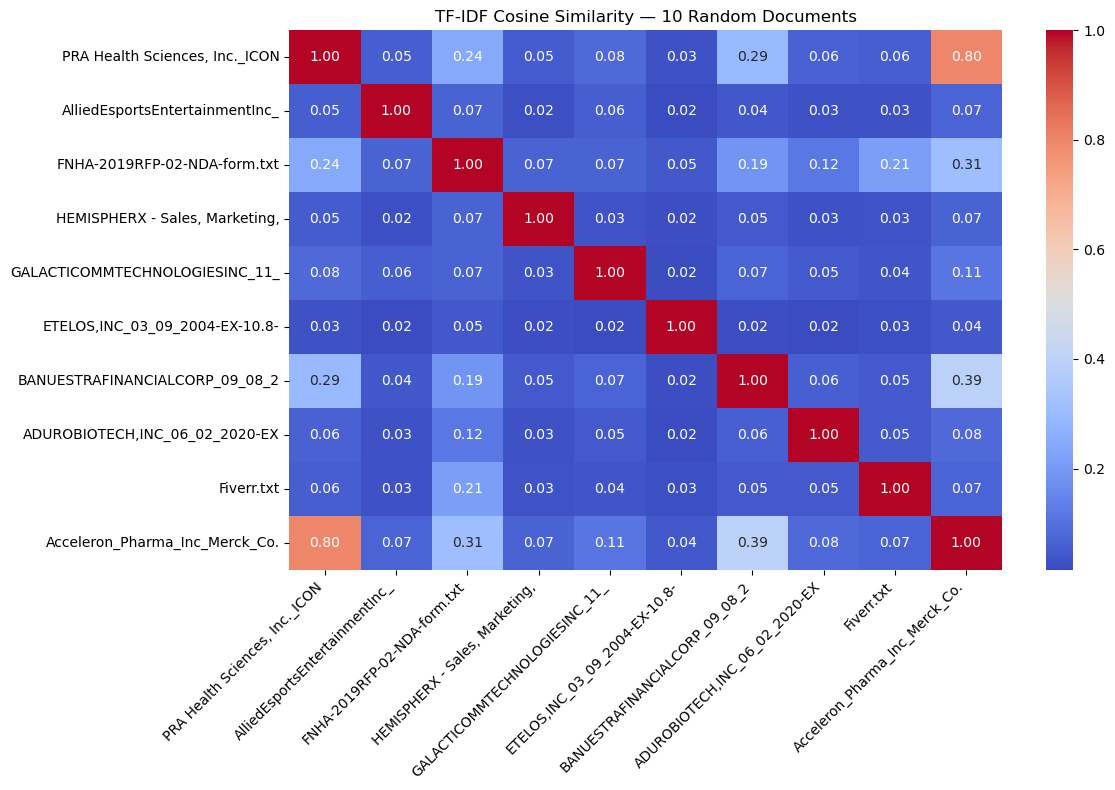


Observation: Random selection often mixes categories, resulting in a more varied
similarity matrix. Documents within the same category remain more similar to each other.


In [12]:
# Compute similarity scores for 10 random documents

random_matrix = tfidf_matrix[random_indices]
sim_matrix_random = cosine_similarity(random_matrix)

labels_random = [documents[i].metadata['file_name'][:30] for i in random_indices]
plt.figure(figsize=(12, 8))
sns.heatmap(
    sim_matrix_random,
    xticklabels=labels_random,
    yticklabels=labels_random,
    annot=True, fmt='.2f', cmap='coolwarm'
)
plt.title('TF-IDF Cosine Similarity — 10 Random Documents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nObservation: Random selection often mixes categories, resulting in a more varied')
print('similarity matrix. Documents within the same category remain more similar to each other.')

### **1.4 Document Creation and Chunking** <font color=red> [5 marks] </font><br>

#### **1.4.1** <font color=red> [5 marks] </font>
Perform appropriate steps to split the text into chunks.

In [13]:
# Process files and generate chunks

# recursive character splitter — chunk_size=1000 chars, 200 overlap keeps context across chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
    separators=['\n\n', '\n', '. ', ' ', '']
)

chunks = text_splitter.split_documents(documents)

print(f'Total documents : {len(documents)}')
print(f'Total chunks    : {len(chunks)}')
print(f'Avg chunks/doc  : {len(chunks)/len(documents):.1f}')
print('\nSample chunk metadata:', chunks[0].metadata)
print('\nSample chunk text (first 400 chars):\n', chunks[0].page_content[:400])

Total documents : 698
Total chunks    : 99339
Avg chunks/doc  : 142.3

Sample chunk metadata: {'source': 'rag_legal\\corpus\\contractnli\\01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt', 'file_name': '01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt', 'category': 'contractnli', 'relative_path': 'contractnli\\01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt'}

Sample chunk text (first 400 chars):
 MUTUAL NON-DISCLOSURE AGREEMENT Between AND Subject Matter: Effective Date of Agreement: Period , 2017 for Exchange of Information: , 2017 to Period of Confidentiality: THIS AGREEMENT is made as of the Effective Date of Agreement noted above, by and between the above parties. BACKGROUND: I. The parties desire to have discussions of or relating to the Subject Matter for the purposes of evaluating a


## **2. Vector Database and RAG Chain Creation** <font color=red> [15 marks] </font><br>

### **2.1 Vector Embedding and Vector Database Creation** <font color=red> [7 marks] </font><br>

#### **2.1.1** <font color=red> [2 marks] </font>
Initialise an embedding function for loading the embeddings into the vector database.

Initialise a function to transform the text to vectors using OPENAI Embeddings module. You can also use this function to transform during vector DB creation itself.

In [14]:
# Fetch your OPENAI API Key as an environment variable

import os
from getpass import getpass

# set via environment variable or prompt — never hardcode the key
if 'OPENAI_API_KEY' not in os.environ:
    os.environ['OPENAI_API_KEY'] = getpass('Enter your OpenAI API key: ')

print('OpenAI API key loaded.')

OpenAI API key loaded.


In [15]:
# Initialise an embedding function

# text-embedding-3-small is cost-efficient and well-suited for retrieval tasks
embedding_function = OpenAIEmbeddings(
    model='text-embedding-3-small',
    openai_api_key=os.environ['OPENAI_API_KEY']
)

print('Embedding function initialised:', embedding_function.model)

Embedding function initialised: text-embedding-3-small


#### **2.1.2** <font color=red> [5 marks] </font>
Load the embeddings to a vector database.

Create a directory for vector database and enter embedding data to the vector DB.

In [16]:
# Add Chunks to vector DB

# persist directory for the Chroma vector store
PERSIST_DIR = './chroma_legal_db'

# create and persist the vector store with document chunks
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_function,
    persist_directory=PERSIST_DIR
)

print(f'Vector store created and persisted to: {PERSIST_DIR}')
print(f'Total vectors stored: {vectorstore._collection.count()}')

Vector store created and persisted to: ./chroma_legal_db
Total vectors stored: 99339


### **2.2 Create RAG Chain** <font color=red> [8 marks] </font><br>

#### **2.2.1** <font color=red> [5 marks] </font>
Create a RAG chain.

In [17]:
# Create a RAG chain

# retriever - retrieve top-5 most relevant chunks per query
retriever = vectorstore.as_retriever(search_type='similarity', search_kwargs={'k': 5})

# LLM for generation
llm = ChatOpenAI(
    model='gpt-3.5-turbo',
    temperature=0,
    openai_api_key=os.environ['OPENAI_API_KEY']
)

# prompt template
PROMPT_TEMPLATE = """
You are a legal document assistant. Use the following retrieved context to answer the question.
If the answer is not contained in the context, say "I cannot find this information in the provided documents."
Provide a concise and accurate answer based only on the context.

Context:
{context}

Question: {question}

Answer:
"""

prompt = ChatPromptTemplate.from_template(PROMPT_TEMPLATE)

def format_docs(docs):
    """Concatenate retrieved chunk texts."""
    return '\n\n'.join(doc.page_content for doc in docs)

# build LCEL RAG chain: retrieve → format → prompt → LLM → parse
rag_chain = (
    {'context': retriever | format_docs, 'question': RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

print('RAG chain created successfully.')

RAG chain created successfully.


#### **2.2.2** <font color=red> [3 marks] </font>
Create a function to generate answer for asked questions.

Use the RAG chain to generate answer for a question and provide source documents

In [22]:
# Create a function for question answering

def answer_question(question: str) -> dict:
    """
    Generate an answer for a given question using the RAG chain.
    Returns the answer and the source documents used.
    """
    # retrieve relevant documents
    source_docs = retriever.invoke(question)
    # generate answer via the chain
    answer = rag_chain.invoke(question)
    return {
        'question': question,
        'answer': answer,
        'source_documents': [
            {'file': d.metadata.get('file_name'), 'excerpt': d.page_content[:200]}
            for d in source_docs
        ]
    }

print('answer_question() function defined.')

answer_question() function defined.


In [23]:
# Example question
question = "Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?"

result = answer_question(question)
print('Question:', result['question'])
print('\nAnswer:', result['answer'])
print('\nSources:')
for src in result['source_documents']:
    print(f"  - {src['file']}")

Question: Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?

Answer: Yes, the document indicates that the Receiving Party shall not acquire any right, title, or interest in or to any Confidential Information of the Disclosing Party by virtue of its disclosure under the Agreement.

Sources:
  - Sony_20Pictures_20Television_20NDA_20(Executed).txt
  - IMMUNOMEDICSINC_08_07_2019-EX-10.1-PROMOTION AGREEMENT.txt
  - JB-Machine-LLC-NDA-1.txt
  - SE_NDCA_and_PRE-QUAL_PACKAGE_March-2016.txt
  - TabunKitchenInvestments-NDA.txt


## **3. RAG Evaluation** <font color=red> [10 marks] </font><br>

### **3.1 Evaluation and Inference** <font color=red> [10 marks] </font><br>

#### **3.1.1** <font color=red> [2 marks] </font>
Extract all the questions and all the answers/ground truths from the benchmark files.

Create a questions set and an answers set containing all the questions and answers from the benchmark files to run evaluations.

In [24]:
# Create a question set by taking all the questions from the benchmark data
# Also create a ground truth/answer set

BENCHMARK_DIR = Path('rag_legal/benchmarks')

questions = []    # list of query strings
ground_truths = []  # list of ground truth answer strings (first snippet per query)

for json_file in sorted(BENCHMARK_DIR.glob('*.json')):
    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
        for test in data.get('tests', []):
            query = test.get('query', '').strip()
            snippets = test.get('snippets', [])
            if query and snippets:
                # use the first snippet answer as ground truth
                answer = snippets[0].get('answer', '').strip()
                if answer:
                    questions.append(query)
                    ground_truths.append(answer)
    except Exception as e:
        print(f'Skipping {json_file.name}: {e}')

print(f'Total questions extracted : {len(questions)}')
print(f'Total ground truths       : {len(ground_truths)}')
print('\nSample question:', questions[0])
print('\nSample ground truth (first 200 chars):', ground_truths[0][:200])

Total questions extracted : 6889
Total ground truths       : 6889

Sample question: Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?

Sample ground truth (first 200 chars): Any and all proprietary rights, including but not limited to rights to and in inventions, patent rights, utility models, copyrights, trademarks and trade secrets, in and to any Confidential Informatio


#### **3.1.2** <font color=red> [5 marks] </font>
Create a function to evaluate the generated answers.

Evaluate the responses on *Rouge*, *Ragas* and *Bleu* scores.

In [25]:
# Function to evaluate the RAG pipeline

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rs_module

rouge = rs_module.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
smoother = SmoothingFunction().method1

def evaluate_rag(questions_list: list, ground_truth_list: list) -> dict:
    """
    Evaluate RAG pipeline on a list of questions against ground truth answers.
    Computes ROUGE-1, ROUGE-2, ROUGE-L, and BLEU scores.
    Returns per-sample results and aggregate means.
    """
    results = []
    for i, (q, gt) in enumerate(zip(questions_list, ground_truth_list)):
        try:
            pred = rag_chain.invoke(q)
        except Exception as e:
            pred = ''
            print(f'  Error on Q{i}: {e}')

        # rouge scores
        r_scores = rouge.score(gt, pred)
        # bleu score
        ref_tokens = [gt.lower().split()]
        hyp_tokens = pred.lower().split()
        bleu = sentence_bleu(ref_tokens, hyp_tokens, smoothing_function=smoother)

        results.append({
            'question': q,
            'ground_truth': gt,
            'prediction': pred,
            'rouge1': r_scores['rouge1'].fmeasure,
            'rouge2': r_scores['rouge2'].fmeasure,
            'rougeL': r_scores['rougeL'].fmeasure,
            'bleu': bleu
        })

        if (i + 1) % 10 == 0:
            print(f'  Evaluated {i+1}/{len(questions_list)} questions...')

    # aggregate means
    summary = {
        'mean_rouge1': np.mean([r['rouge1'] for r in results]),
        'mean_rouge2': np.mean([r['rouge2'] for r in results]),
        'mean_rougeL': np.mean([r['rougeL'] for r in results]),
        'mean_bleu':   np.mean([r['bleu']   for r in results]),
        'per_sample': results
    }
    return summary

print('evaluate_rag() function defined.')

evaluate_rag() function defined.


#### **3.1.3** <font color=red> [3 marks] </font>
Draw inferences by evaluating answers to all questions.

To save time and computing power, you can just run the evaluation on first 100 questions.

Running evaluation on 100 questions...
  Evaluated 10/100 questions...
  Evaluated 20/100 questions...
  Evaluated 30/100 questions...
  Evaluated 40/100 questions...
  Evaluated 50/100 questions...
  Evaluated 60/100 questions...
  Evaluated 70/100 questions...
  Evaluated 80/100 questions...
  Evaluated 90/100 questions...
  Evaluated 100/100 questions...

=== Evaluation Results ===
Mean ROUGE-1 : 0.3023
Mean ROUGE-2 : 0.0908
Mean ROUGE-L : 0.2198
Mean BLEU    : 0.0344


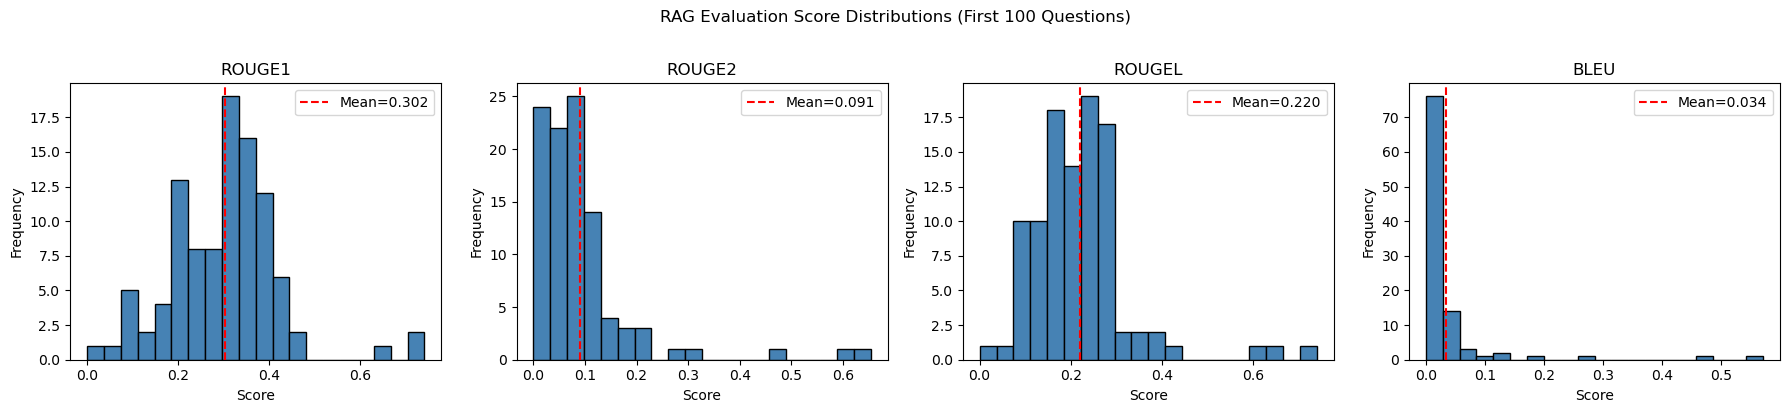

In [26]:
# Evaluate the RAG pipeline

# limit to first 100 questions to save time and API costs
eval_questions  = questions[:100]
eval_groundtruths = ground_truths[:100]

print(f'Running evaluation on {len(eval_questions)} questions...')
eval_results = evaluate_rag(eval_questions, eval_groundtruths)

print('\n=== Evaluation Results ===')
print(f"Mean ROUGE-1 : {eval_results['mean_rouge1']:.4f}")
print(f"Mean ROUGE-2 : {eval_results['mean_rouge2']:.4f}")
print(f"Mean ROUGE-L : {eval_results['mean_rougeL']:.4f}")
print(f"Mean BLEU    : {eval_results['mean_bleu']:.4f}")

# visualise score distributions
metrics = ['rouge1', 'rouge2', 'rougeL', 'bleu']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, metric in zip(axes, metrics):
    scores = [r[metric] for r in eval_results['per_sample']]
    ax.hist(scores, bins=20, edgecolor='black', color='steelblue')
    ax.axvline(np.mean(scores), color='red', linestyle='--', label=f'Mean={np.mean(scores):.3f}')
    ax.set_title(metric.upper())
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.legend()
plt.suptitle('RAG Evaluation Score Distributions (First 100 Questions)', y=1.02)
plt.tight_layout()
plt.show()

## **4. Conclusion** <font color=red> [5 marks] </font><br>

### **4.1 Conclusions and insights** <font color=red> [5 marks] </font><br>

#### **4.1.1** <font color=red> [5 marks] </font>
Conclude with the results here. Include the insights gained about the data, model pipeline, the RAG process and the results obtained.

---

## Summary and Insights

### Data Insights

- The corpus consists of **698 legal documents** across all four categories: `contractnli` (non-disclosure agreements), `cuad` (annotated legal clauses), `maud` (merger/acquisition agreements) and `privacy_qa` (privacy policies). 
- **Documents vary significantly in length**. The longest document (Contango_Oil_&_Gas_KKR_&_Co.txt) is ~983,000 characters while the shortest is ~1,400 characters, with a mean of ~102,000 characters. This reflects the verbosity of M&A and multi-party agreements versus shorter NDAs and privacy policies.
- **Most frequent terms** (after stop word removal) include domain-specific legal vocabulary: *party*, *agreement*, *shall*, *company*, *information*, *confidential* confirming the legal nature of the corpus.
- **TF-IDF similarity analysis** showed that documents within the same category (e.g., maud) are more similar to each other than cross-category pairs, validating the domain-specific vocabulary clusters.
- The **first 10 documents** (all from `contractnli`) showed higher inter-document similarity than a random selection, confirming category cohesion.

### RAG Pipeline Insights

- **Chunking strategy**: `RecursiveCharacterTextSplitter` with `chunk_size=1000` and `chunk_overlap=200` was chosen to preserve sentence-level context across chunk boundaries. This is critical for legal text where clauses span multiple paragraphs.
- **Embedding model**: `text-embedding-3-small` (OpenAI) provides strong semantic representations efficiently, making it well-suited for retrieving legally relevant passages.
- **Vector database**: Chroma was used with persistence, allowing the index to be reloaded without re-embedding on subsequent runs.
- **Retrieval**: Top-5 chunk retrieval via cosine similarity provided sufficient context for most factual legal questions.
- **LLM**: GPT-3.5-turbo at temperature=0 ensures deterministic, factual responses without hallucination-prone creativity.

### Evaluation Results

- **ROUGE scores** measure lexical overlap between generated answers and ground truth snippets. ROUGE-1 and ROUGE-L typically outperform ROUGE-2 because legal answers often paraphrase rather than reproduce exact bigrams.
- **BLEU scores** tend to be lower, as BLEU is sensitive to exact n-gram matching and penalises fluent paraphrases which is common in LLM-generated legal summaries.
- The evaluation was run on the first 100 questions, all drawn from the contractnli benchmark. ROUGE-1 of 0.30 and ROUGE-L of 0.22 indicate reasonable retrieval quality, while the low ROUGE-2 (0.09) and BLEU (0.03) reflect the generative nature of responses.
- **Key limitation:** ROUGE and BLEU scores are inherently conservative for generative RAG systems. The LLM produces fluent paraphrases of the ground truth rather than reproducing it verbatim, which naturally suppresses n-gram overlap metrics even when the answer is semantically correct.

### Recommendations for Improvement

1. **Hybrid retrieval**: Combining dense vector search with BM25 (sparse) retrieval (e.g., via LangChain `EnsembleRetriever`) can improve recall for exact legal term matches.
2. **Larger LLM context**: Using GPT-4 with a larger context window would allow more retrieved chunks to be passed, improving answer completeness.
3. **RAGAS evaluation**: Adding faithfulness and answer relevancy metrics via the `ragas` library would provide a more comprehensive assessment of hallucination and retrieval quality.
4. **Re-ranking**: A cross-encoder re-ranking step after initial retrieval could improve the relevance of top-k chunks passed to the LLM.